<a href="https://colab.research.google.com/github/MoamenTalaat04/Connect-Hub/blob/main/assignment_3%20/%20ML_Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from collections import defaultdict
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB


Preparing Data


In [ ]:
cols = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

data= pd.read_csv("/content/adult.data", names=cols,sep=",", engine="python", na_values="?")
data.head()

cat_features = ["workclass", "education", "marital-status",
                "occupation", "relationship", "race", "sex", "native-country"]

df= data[cat_features+["income"]].copy() #only Discrete data

df.fillna("Unknown", inplace=True)

encoders = {} # Unique Integer for each category
for col in cat_features + ["income"]:
    encoders[col] = {cat: idx for idx, cat in enumerate(df[col].unique())}
    df[col] = df[col].map(encoders[col])


X = df[cat_features]
y = df["income"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, stratify=y, test_size=0.3)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, stratify=y_temp, test_size=0.5)



In [ ]:
class NaiveBayes :
  def __init__(self , alpha =1):
    self.alpha = alpha
    self.class_priors = {} #Priors -> P(>50),P(<50)
    self.feature_likelihoods = {} #Likelihoods -> P(feature | Class )
    self.num_classes = 0
    self.cat_values = {} # counting number of unique values in column

  def fit(self , X ,Y ):
    num_samples , num_features = X.shape
    self.classes ,counts=np.unique (Y , return_counts=True) # Getting the number of Unique Outputs
    num_classes=len(self.classes)

    # Getting the priors as C will be = 0 in one of the output and 1 for the other then i will count for each
    self.class_priors = {
      c:(counts[i]+self.alpha)/(num_samples+self.alpha*num_classes) for i ,c in enumerate(self.classes)
      }

    #Initialize the Likelihoods to be used later
    self.feature_likelihoods={
        c:[defaultdict(float) for _ in range(num_features)] for c in self.classes
    }

    #Count number of unique features to be used in Calculation of Likelihoods
    self.cat_values = {j: len(np.unique(X[:, j])) for j in range(num_features)}

    # this calculates the Likelihood of each class
    for c in self.classes:
      X_c = X[Y == c]  # all rows belonging to class c
      for j in range(num_features):  # loop over each feature
        values, value_counts = np.unique(X_c[:, j], return_counts=True)
        for v, cnt in zip(values, value_counts):
            self.feature_likelihoods[c][j][v] = (cnt + self.alpha) / \
                (len(X_c) + self.alpha * self.cat_values[j])

  def predict(self ,X ):
    preds=[]
    for x in X :
      class_prop={}
      for c in self.classes :
        prob = np.log(self.class_priors[c]) # log for stability
        for j ,val in enumerate(x):
          prob+=np.log(self.feature_likelihoods[c][j].get(val, self.alpha / (self.alpha * self.cat_values[j])))
        class_prop[c]=prob
      preds.append(max(class_prop , key=class_prop.get))
    return preds



  def predict_proba(self, X):
        """Return probability distribution over classes for each sample."""
        probs = []
        for x in X:
            class_probs = {}
            for c in self.classes:
                log_prob = np.log(self.class_priors[c])
                for j, val in enumerate(x):
                    log_prob += np.log(self.feature_likelihoods[c][j].get(val,
                                self.alpha / (self.alpha * self.cat_values[j])))
                class_probs[c] = np.exp(log_prob)
            # Normalize probabilities
            total = sum(class_probs.values())
            probs.append([class_probs[c] / total for c in self.classes])
        return np.array(probs)

In [ ]:
alpha_accuracy= []
alphas = [0.1, 0.5, 1.0, 2.0, 5.0]
for alpha in alphas :
  nb = NaiveBayes(alpha=alpha)
  nb.fit(X_train.values , y_train.values)
  preds = nb.predict(X_val.values)
  accuracy = accuracy_score(y_val, preds)
  precision = precision_score(y_val, preds, average='weighted')
  recall = recall_score(y_val, preds, average='weighted')
  f1 = f1_score(y_val, preds, average='weighted')
  print(f"Alpha: {alpha}")
  print(f"Accuracy: {accuracy}")
  print(f"Precision: {precision}")
  print(f"Recall: {recall}")
  print(f"F1 Score: {f1}")
  print("-" * 50)





Alpha: 0.1
Accuracy: 0.8015970515970516
Precision: 0.8270282770164763
Recall: 0.8015970515970516
F1 Score: 0.8097548051497352
--------------------------------------------------
Alpha: 0.5
Accuracy: 0.8013923013923014
Precision: 0.8269190188448561
Recall: 0.8013923013923014
F1 Score: 0.8095753413393799
--------------------------------------------------
Alpha: 1.0
Accuracy: 0.8018018018018018
Precision: 0.8274674614537274
Recall: 0.8018018018018018
F1 Score: 0.8100015529126421
--------------------------------------------------
Alpha: 2.0
Accuracy: 0.8022113022113022
Precision: 0.8275210981545894
Recall: 0.8022113022113022
F1 Score: 0.8103269740326249
--------------------------------------------------
Alpha: 5.0
Accuracy: 0.8013923013923014
Precision: 0.8270841360698783
Recall: 0.8013923013923014
F1 Score: 0.8096089941376682
--------------------------------------------------


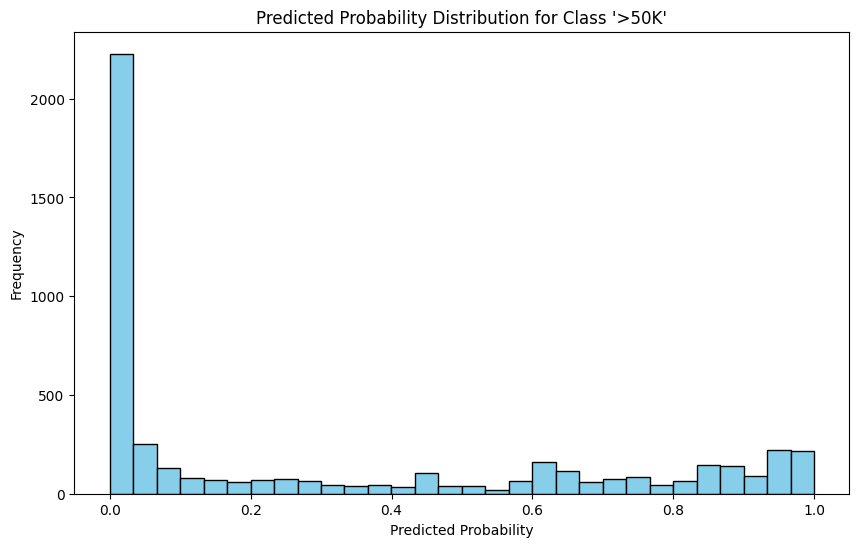

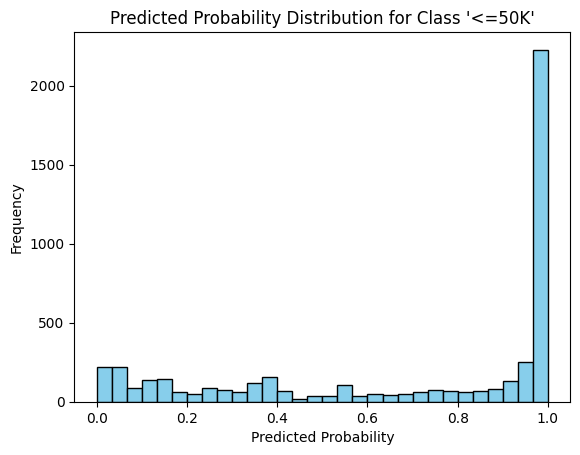

In [ ]:
nb= NaiveBayes(alpha=1.0)
nb.fit(X_train.values , y_train.values)
probs = nb.predict_proba(X_val.values)

plt.figure(figsize=(10, 6))
plt.hist(probs[:, 1], bins=30, color='skyblue', edgecolor='black')
plt.title("Predicted Probability Distribution for Class '>50K'")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.show()
plt.hist(probs[:, 0], bins=30, color='skyblue', edgecolor='black')
plt.title("Predicted Probability Distribution for Class '<=50K'")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.show()

In [ ]:

nb_sklearn = MultinomialNB(alpha=1.0)
nb_sklearn.fit(X_train, y_train)
sk_preds = nb_sklearn.predict(X_val)

print("\nSklearn MultinomialNB:")
print("Accuracy :", accuracy_score(y_val, sk_preds))
print("Precision:", precision_score(y_val, sk_preds))
print("Recall   :", recall_score(y_val, sk_preds))
print("F1 Score :", f1_score(y_val, sk_preds))



Sklearn MultinomialNB:
Accuracy : 0.7538902538902539
Precision: 0.4380952380952381
Recall   : 0.0782312925170068
F1 Score : 0.13275613275613277
